# Deep Learning for Satellite Flood Detection (End-to-End Pipeline)

## **Project Overview**
This notebook demonstrates a complete workflow for detecting flood events using **Google Earth Engine (GEE)** and **Deep Learning (TensorFlow/Keras)**. Unlike standard thresholding methods (NDWI), we train a **U-Net Neural Network** to learn the spectral signature of water from raw MODIS satellite imagery.

### **Workflow:**
1.  **Data Extraction:** Automatically mining the *Global Flood Database* to export thousands of training patches from 5 major historical floods (India, China, Europe, etc.).
2.  **Data Pipeline:** Parsing `TFRecord` files directly from Google Drive into a TensorFlow dataset.
3.  **Model Training:** Training a U-Net architecture with **Weighted Loss** to handle class imbalance (since water is rare compared to land).
4.  **Inference:** Deploying the model to detect floods in a completely new locations and calculating flood impact metrics.

---
**Author:** Shailesh Kumar Jha, Ph.D. Scholar IIT Mandi

**Tech Stack:** Python, Google Earth Engine API, TensorFlow, Matplotlib

In [46]:
# @title 0. Install Dependencies
# Run this cell first to ensure all libraries are installed.
!pip install geemap
!pip install earthengine-api --upgrade

# **Prerequisite: Creating a Google Cloud Project**

To use Google Earth Engine (GEE) with Python or Google Colab, you need a **Google Cloud Project**. This project acts as a "container" for your work, tracking your usage and permissions.

If you do not have a Project ID yet, follow these steps:

### **Step 1: Log in to the Google Cloud Console**
1.  Go to the **[Google Cloud Console](https://console.cloud.google.com/)**.
2.  Sign in with the same Google Account you use for Earth Engine.

### **Step 2: Create a New Project**
1.  In the top navigation bar (next to the Google Cloud logo), click the **Project Dropdown** (it might say "Select a project").
2.  In the window that opens, click **"NEW PROJECT"** (usually in the top right corner).

### **Step 3: Naming & ID (Crucial Step)**
1.  **Project Name:** Enter a friendly name (e.g., `Flood-Detection-2025`). This can be anything.
2.  **Project ID:** Look immediately below the name field.
    * Google will auto-generate an ID (e.g., `flood-detection-2025-48291`).
    * **Edit it now** if you want a cleaner ID (e.g., `my-flood-research`).
    * **⚠️ Important:** This ID must be unique globally, and **you cannot change it later**.
3.  Click **CREATE** and wait a moment.

### **Step 4: Enable the Earth Engine API**
Just creating a project isn't enough; you must explicitly "turn on" Earth Engine.
1.  Use the **Search Bar** at the very top of the console.
2.  Type **"Earth Engine API"** and select "Google Earth Engine API" from the Marketplace results.
3.  Click the blue **ENABLE** button.

### **Step 5: Get Your Project ID**
You will need to copy your **Project ID** (not the Name!) into the Python code below.
* You can find it on the **Cloud Console Dashboard** in the "Project Info" card.
* Example ID: `flood-research-2025`

---

In [47]:
# @title 1. Setup & Authentication
import ee
import geemap
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# --- CONFIGURATION ---
# ❗ IMPORTANT: Replace with your Google Cloud Project ID
PROJECT_ID = 'flood-detection-2025-480013' # Change this to your Project ID
# ---------------------

try:
    # Attempt to initialize with the specified project
    ee.Initialize(project=PROJECT_ID)
    print(f"✅ Successfully connected to Earth Engine Project: {PROJECT_ID}")
except Exception:
    # If failed, trigger the authentication flow
    print("⚠️ Authentication required. Follow the steps in the popup...")
    ee.Authenticate()
    # Retry initialization after auth
    ee.Initialize(project=PROJECT_ID)
    print(f"✅ Successfully initialized Project: {PROJECT_ID}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Successfully connected to Earth Engine Project: flood-detection-2025-480013


## **2. Data Engineering: The "World Tour" Export**

To build a robust model, we cannot train on a single event. A model trained only on India might fail in Brazil due to soil color differences. We script Earth Engine to find **5 major flood events** from history across different continents.

### **Key Concepts Explained:**

#### **1. What is "Severity" (Label Filtering)?**
We filter events using the `dfo_severity` score from the **Dartmouth Flood Observatory (DFO)**.
* **Class 1 (Large):** Significant damage to structures/agriculture.
* **Class 1.5 (Very Large):** >15 year recurrence interval.
* **Class 2 (Extreme):** >100 year recurrence interval.
* **Our Strategy:** We filter for `Severity > 1.5`. By training only on "Extreme" events, we ensure the "Water" signal is massive and unmistakable, reducing noise in our training data.

#### **2. What are TFRecords?**
Deep Learning models require massive throughput. Loading thousands of individual `.png` or `.tif` images is slow and inefficient.
* **TFRecord** is TensorFlow's native binary format. It serializes the image data (pixels) and metadata (labels) into a single byte stream.
* **Benefit:** This allows the GPU to stream data continuously without waiting for file I/O operations, significantly speeding up training.

#### **3. The Satellite Physics (MODIS Bands)**
We use the **MODIS (Terra/Aqua)** satellite sensor. While its resolution is coarse (500m), it revisits the earth daily, making it ideal for tracking fast-moving floods. We select three specific parts of the light spectrum:



* **Band 1 (Red):** Absorbed by water, reflected by soil.
* **Band 2 (Near Infrared - NIR):** The most critical band. Water absorbs almost 100% of NIR light (appearing black), while vegetation reflects it strongly (appearing bright).
* **Band 6 (Shortwave Infrared - SWIR):** Helps differentiate between muddy water and clouds/snow.

**The Result:** A 3-channel stack (Red, NIR, SWIR) where water stands out as a unique, dark spectral signature compared to the bright land.

## **3. The Dataset: Global Flood Database v1**

**"Garbage In, Garbage Out."**
In Deep Learning, the quality of your labels determines the success of your model. For this project, we rely on the **Global Flood Database (GFD)**, the world's most comprehensive archive of historical flood maps.


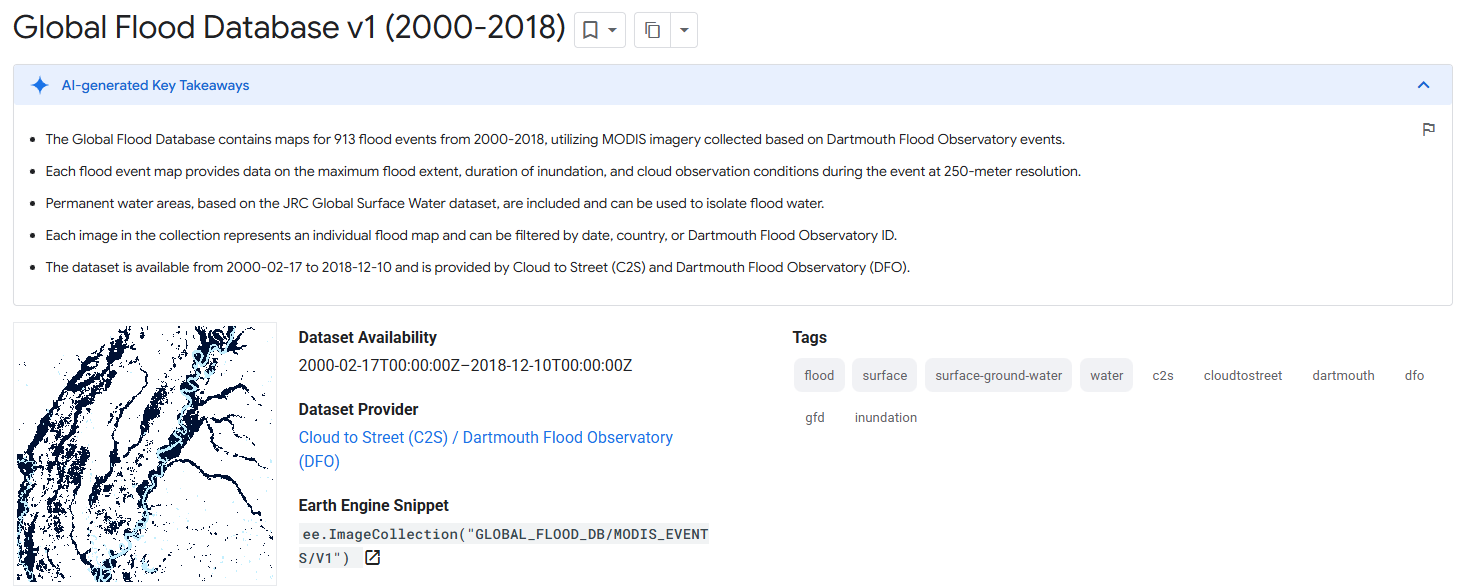

### **Dataset Overview**
* **Provider:** Cloud to Street / Dartmouth Flood Observatory (DFO)
* **Scale:** Contains maps for **913 unique flood events** across the globe.
* **Time Period:** 2000 to 2018.
* **Source:** Derived from Terra & Aqua MODIS imagery (250m resolution).

### **Why this Dataset?**
To train a U-Net, we need **Ground Truth**—accurate maps showing exactly where water was during a disaster. The GFD provides this in the `flooded` band, which serves as our **Target Variable (Y)**. We pair this with raw satellite imagery (Input X) to teach the model to recognize water patterns.

### **Key Attributes We Use:**
1.  **`flooded`**: A binary mask where `1` = Maximum Flood Extent and `0` = Dry Land.
2.  **`dfo_severity`**: A numeric score of the flood's intensity.
    * *1.5 = Very Large* (>15 year recurrence)
    * *2.0 = Extreme* (>100 year recurrence)
    * *Strategy:* We filters for **Severity > 1.5** to ensure we train on massive, unambiguous water signals.
3.  **`system:time_start`**: The date of the event, allowing us to temporally match the input satellite images to the flood map.

In [48]:
# @title 4. Execute Data Export
import time
import os
import glob

# Configuration
GFD_COLLECTION = 'GLOBAL_FLOOD_DB/MODIS_EVENTS/V1'
MODIS_COLLECTION = 'MODIS/061/MOD09GA'
EXPORT_FOLDER = 'GEE_FLOOD_DATASET'
DRIVE_PATH = f'/content/drive/My Drive/{EXPORT_FOLDER}' # Local path to check files

# 1. Find Major Global Floods (Severity > 1.5)
print("🌍 Searching for major flood events (Severity > 1.5)...")
# Filter OUT 'AUS' to avoid the known missing data error
events = ee.ImageCollection(GFD_COLLECTION) \
    .filter(ee.Filter.gt('dfo_severity', 1.5)) \
    .filter(ee.Filter.neq('cc', 'AUS')) \
    .limit(5)

event_list = events.toList(5)
count = event_list.size().getInfo()
print(f"✅ Found {count} extreme flood events (Skipping AUS). Checking Drive for existing files...")

# 2. Loop & Export
for i in range(count):
    # Extract Event Metadata
    event = ee.Image(event_list.get(i))
    event_id = event.get('id').getInfo()
    country = event.get('cc').getInfo()
    year = ee.Date(event.get('system:time_start')).get('year').getInfo()

    # --- SMART CHECK: Do not download if already present ---
    # We look for any file that starts with this event's ID
    file_prefix = f'training_patch_{country}_{event_id}'
    existing_files = glob.glob(f"{DRIVE_PATH}/{file_prefix}*")

    if len(existing_files) > 0:
        print(f"⏩ Skipping Event {i+1}/{count}: {country} ({year}) | ID: {event_id} (Files already exist)")
        continue
    # -------------------------------------------------------

    print(f"🚀 Processing Event {i+1}/{count}: {country} ({year}) | ID: {event_id}")

    # Define Region & Time Window
    roi = event.geometry()
    flood_date = ee.Date(event.get('system:time_start'))

    # Fetch Satellite Image (Input Features)
    modis = ee.ImageCollection(MODIS_COLLECTION) \
        .filterDate(flood_date, flood_date.advance(3, 'day')) \
        .filterBounds(roi) \
        .first()

    # Pre-processing
    input_image = modis.select(['sur_refl_b01', 'sur_refl_b02', 'sur_refl_b06']).divide(10000).float()
    label_image = event.select(['flooded'], ['label']).unmask(0).float()
    stacked_image = input_image.addBands(label_image)

    # Export Task
    task_name = f'Flood_Export_{country}_{year}_{event_id}'
    task = ee.batch.Export.image.toDrive(
        image=stacked_image,
        description=task_name,
        folder=EXPORT_FOLDER,
        fileNamePrefix=file_prefix,
        region=roi,
        scale=500,
        fileFormat='TFRecord',
        maxPixels=1e13,
        formatOptions={
            'patchDimensions': [256, 256],
            'compressed': True,
            'collapseBands': True
        }
    )
    task.start()

print("\n⏳ Status check complete. New tasks (if any) submitted to Task Manager.")

🌍 Searching for major flood events (Severity > 1.5)...
✅ Found 5 extreme flood events (Skipping AUS). Checking Drive for existing files...
⏩ Skipping Event 1/5: UKR, POL, ROU, BGR, BLR, SRB, HRV, HUN, BIH, SVN (2000) | ID: 1595 (Files already exist)
⏩ Skipping Event 2/5: CHN, IND, NPL, BGD, BTN (2000) | ID: 1641 (Files already exist)
⏩ Skipping Event 3/5: RUS, CHN, MNG, KAZ (2001) | ID: 1725 (Files already exist)
⏩ Skipping Event 4/5: IND, BGD (2001) | ID: 1747 (Files already exist)
⏩ Skipping Event 5/5: VNM, THA, LAO, KHM (2001) | ID: 1781 (Files already exist)

⏳ Status check complete. New tasks (if any) submitted to Task Manager.


In [49]:
# @title Check Dataset Size
import tensorflow as tf
import glob

# 1. Get File List
files = glob.glob(f'/content/drive/My Drive/{EXPORT_FOLDER}/*.tfrecord.gz')
print(f"📦 Found {len(files)} TFRecord files.")

# 2. Count Individual Patches (The Chips)
def count_dataset(files):
    # Create a dataset that reads the files
    ds = tf.data.TFRecordDataset(files, compression_type='GZIP')
    # Loop through and count (this might take a minute)
    count = 0
    for _ in ds:
        count += 1
    return count

print("⏳ Counting total training patches (this may take 30s)...")
total_patches = count_dataset(files)

print(f"\n✅ TOTAL TRAINING IMAGES: {total_patches}")
print("------------------------------------------------")
if total_patches < 500:
    print("⚠️ Recommendation: YES, you need more data.")
elif total_patches < 2000:
    print("👍 Recommendation: Good for a tutorial, but more would improve accuracy.")
else:
    print("🚀 Recommendation: Excellent! You have plenty of data.")

📦 Found 6 TFRecord files.
⏳ Counting total training patches (this may take 30s)...

✅ TOTAL TRAINING IMAGES: 2202
------------------------------------------------
🚀 Recommendation: Excellent! You have plenty of data.


### **5. The Deep Learning Model: U-Net**

We employ the **U-Net architecture**, a specialized Convolutional Neural Network (CNN) originally designed for biomedical imaging (diagnosing tumors) but now considered the "Gold Standard" for satellite mapping.
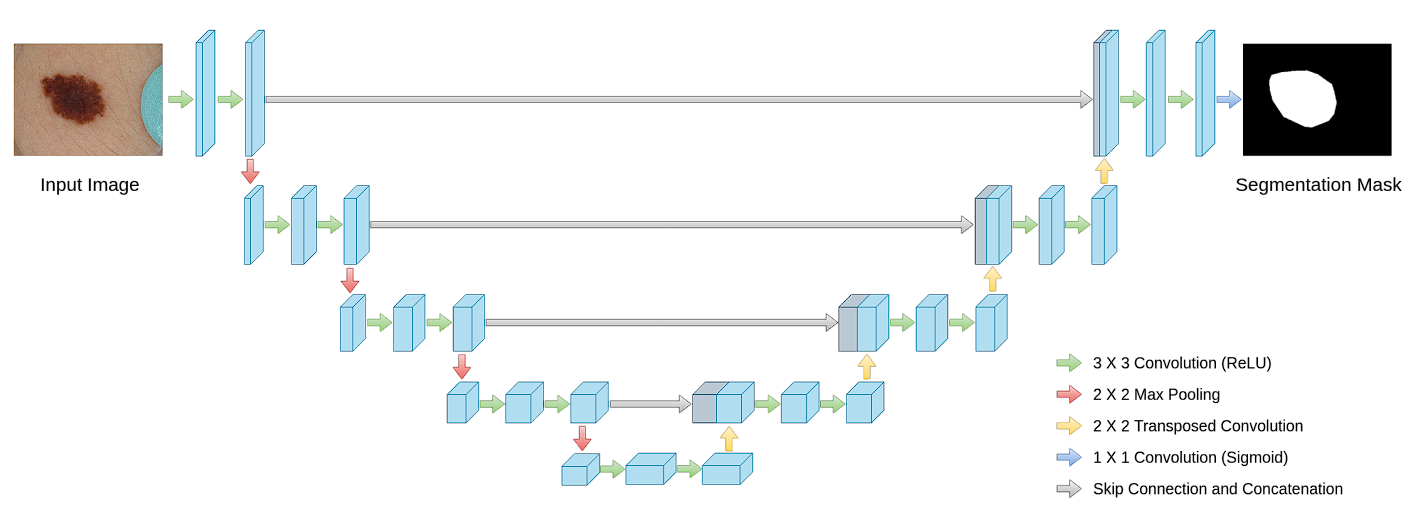


### **Why U-Net? (Segmentation vs. Classification)**
To understand why we chose U-Net, we must understand the task:
* **Standard AI (ResNet/VGG):** Performs *Image Classification*. It looks at an image and says, "This image contains water."
* **Our Goal (U-Net):** Performs *Semantic Segmentation*. It looks at an image and classifies **every single pixel**. It says, "Pixel (10,10) is a House, Pixel (10,11) is Flood Water."

### **The Architecture: A "U" Shape**
The model looks like the letter "U" because it has two symmetric halves:

#### **1. The Encoder (The "Contracting" Path)**
The left side of the "U" acts like a standard CNN. It progressively shrinks the image size (downsampling) while increasing the depth of features.
* **What it does:** It sacrifices spatial resolution (where things are) to learn **Context** (what things are).
* **Example:** It learns that "Dark, smooth textures surrounded by green vegetation usually indicate a river."

#### **2. The Bottleneck**
This is the bottom of the "U". It is the deepest point of the network where the image is compressed into a tiny, abstract representation. It holds the "concept" of the flood without the fine details.

#### **3. The Decoder (The "Expanding" Path)**
The right side of the "U" works in reverse. It upsamples the tiny features back to the original `256x256` image size.
* **What it does:** It recovers the spatial resolution to give us a precise map.



#### **4. Skip Connections (The Secret Sauce)**
This is the critical innovation of U-Net. As we shrink an image in the Encoder, we lose fine details (edges, boundaries). When the Decoder tries to zoom back in, the result would normally be blurry.
* **The Solution:** U-Net "teleports" high-resolution feature maps from the Encoder directly to the Decoder.
* **The Result:** The Decoder has both the **Context** (from the Bottleneck) and the **Sharp Edges** (from the Skip Connections), allowing it to draw crisp river boundaries.

---

### **The Mathematical Challenge: Class Imbalance**
Satellite flood detection suffers from a massive data imbalance. In any given satellite image, **95% of pixels are Land, and only ~5% are Water.**



#### **The "Lazy Student" Problem**
If we use standard training math, the model discovers a cheat code: *"If I just guess 'Land' for every single pixel, I will achieve 95% accuracy!"*
The model minimizes error by ignoring the flood entirely.

#### **Our Solution: Weighted Loss**
We implement a **Weighted Cross Entropy Loss**. We mathematically penalize the model **50 times more** for missing a water pixel than for missing a land pixel.
$$Loss = - (Weight_{water} \times y \log(p) + Weight_{land} \times (1-y) \log(1-p))$$
This forces the model to pay extreme attention to the minority class (Water), ensuring even small creeks are detected.

In [50]:
# @title 6. Define Model & Data Pipeline (Configurable Depth)
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. Custom Loss Function ---
def weighted_bce(y_true, y_pred):
    class_weights = tf.constant([1.0, 50.0])
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.expand_dims(bce, axis=-1)
    weight_vector = y_true * class_weights[1] + (1. - y_true) * class_weights[0]
    return tf.reduce_mean(weight_vector * bce)

# --- 2. Helper: Convolution Block ---
def conv_block(inputs, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

# --- 3. The U-Net Architecture ---
def unet_model(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # ================= ENCODER (Downsampling) =================

    # --- Level 1 ---
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    p1 = layers.Dropout(0.1)(p1)

    # --- Level 2 ---
    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    p2 = layers.Dropout(0.1)(p2)

    # --- Level 3 (Uncomment for 3-Level Depth) ---
    # c3 = conv_block(p2, 128)
    # p3 = layers.MaxPooling2D((2, 2))(c3)
    # p3 = layers.Dropout(0.2)(p3)

    # --- Level 4 (Uncomment for 4-Level Depth) ---
    # c4 = conv_block(p3, 256)
    # p4 = layers.MaxPooling2D((2, 2))(c4)
    # p4 = layers.Dropout(0.2)(p4)

    # ================= BOTTLENECK =================

    # Current: 2-Level Bottleneck (Connects to p2)
    b = conv_block(p2, 128)

    # Option: 3-Level Bottleneck (Uncomment and comment out above)
    # b = conv_block(p3, 256)

    # Option: 4-Level Bottleneck (Uncomment and comment out above)
    # b = conv_block(p4, 512)

    # ================= DECODER (Upsampling) =================

    # --- Level 4 Up (Uncomment for 4-Level Depth) ---
    # u6 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(b)
    # u6 = layers.concatenate([u6, c4])
    # u6 = layers.Dropout(0.2)(u6)
    # c6 = conv_block(u6, 256)
    # b = c6 # Reassign b so the next layer connects correctly

    # --- Level 3 Up (Uncomment for 3-Level Depth) ---
    # u7 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(b)
    # u7 = layers.concatenate([u7, c3])
    # u7 = layers.Dropout(0.2)(u7)
    # c7 = conv_block(u7, 128)
    # b = c7 # Reassign b so the next layer connects correctly

    # --- Level 2 Up ---
    # Note: Input is 'b'. If Level 3/4 are active, 'b' is updated above.
    u8 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(b)
    u8 = layers.concatenate([u8, c2])
    u8 = layers.Dropout(0.1)(u8)
    c8 = conv_block(u8, 64)

    # --- Level 1 Up ---
    u9 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(c8)
    u9 = layers.concatenate([u9, c1])
    u9 = layers.Dropout(0.1)(u9)
    c9 = conv_block(u9, 32)

    # --- OUTPUT ---
    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(c9)

    return models.Model(inputs, outputs)

# --- 4. Data Pipeline ---
def parse_tfrecord(example_proto):
    features_dict = {'sur_refl_b01': tf.io.FixedLenFeature([4, 256, 256], tf.float32)}
    parsed_features = tf.io.parse_single_example(example_proto, features_dict)
    image = parsed_features['sur_refl_b01']
    image = tf.transpose(image, [1, 2, 0])
    inputs = tf.clip_by_value(image[:, :, 0:3], 0.0, 1.0)
    labels = image[:, :, 3:]
    return inputs, labels

def has_water(inputs, labels):
    return tf.reduce_sum(labels) > 50

# --- 5. Verify ---
temp_model = unet_model()
print(f"✅ Configurable U-Net defined.")
print(f"   Current Depth: 2 Levels")
print(f"   Total Parameters: {temp_model.count_params():,}")

✅ Configurable U-Net defined.
   Current Depth: 2 Levels
   Total Parameters: 469,089


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


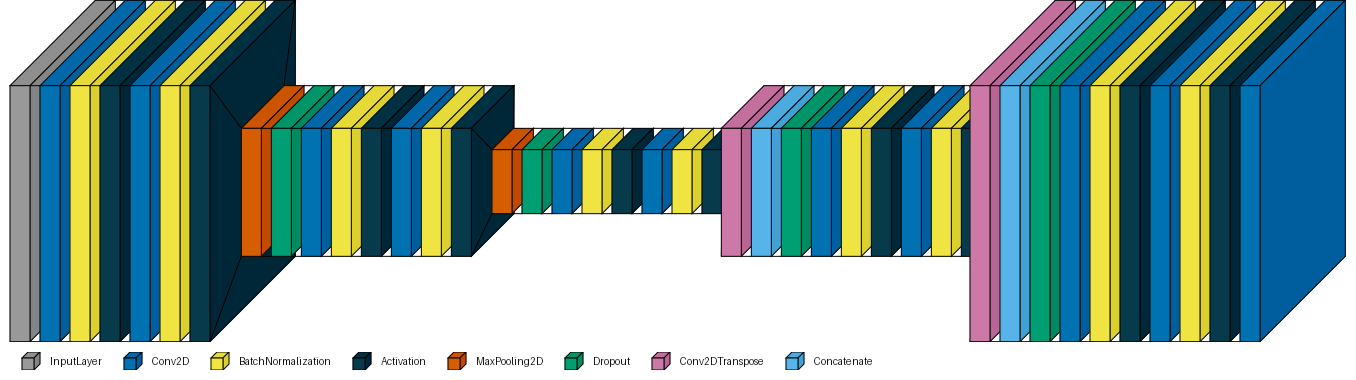

In [51]:
# @title 6.1 Visualize Model
# 1. Install library
!pip install visualkeras

import visualkeras
import tensorflow as tf
from tensorflow.keras import layers
from collections import defaultdict

# 2. Instantiate Model
temp_model = unet_model(input_shape=(256, 256, 3))

# --- FIX FOR KERAS 3 ---
for layer in temp_model.layers:
    try:
        layer.output_shape = layer.output.shape
    except AttributeError:
        pass
# -----------------------

# 3. Define Colorblind-Friendly Palette (Okabe-Ito)
# We map specific Layer Classes to RGB Colors
color_map = defaultdict(dict)

# Blue (Conv2D)
color_map[layers.Conv2D]['fill'] = '#0072B2'
# Vermilion (Max Pooling)
color_map[layers.MaxPooling2D]['fill'] = '#D55E00'
# Bluish Green (Dropout)
color_map[layers.Dropout]['fill'] = '#009E73'
# Yellow (Batch Norm)
color_map[layers.BatchNormalization]['fill'] = '#F0E442'
# Sky Blue (Concatenate / Skip Connections)
color_map[layers.Concatenate]['fill'] = '#56B4E9'
# Reddish Purple (Up-Sampling / Transpose)
color_map[layers.Conv2DTranspose]['fill'] = '#CC79A7'
# Grey (Input)
color_map[layers.InputLayer]['fill'] = '#999999'

# 4. Generate & Display
try:
    img = visualkeras.layered_view(
        temp_model,
        legend=True,
        color_map=color_map,
        scale_xy=1,
        scale_z=0.1,
        max_z=100
    )
    display(img)
except Exception as e:
    print(f"Visualization Error: {e}")

In [52]:
# --- 4. Instantiate & Inspect Model ---
# We create a dummy model just to print the summary
temp_model = unet_model(input_shape=(256, 256, 3))

# 1. Print the full layer-by-layer architecture
print("\n--- Model Architecture Summary ---")
temp_model.summary()

# 2. Print Key Statistics
total_params = temp_model.count_params()
trainable_params = np.sum([tf.keras.backend.count_params(w) for w in temp_model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n📊 --- Model Statistics ---")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Model Depth:          2 Levels (Standard U-Net)")
print(f"Input Shape:          (256, 256, 3)")
print("---------------------------")


--- Model Architecture Summary ---


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_164 (Conv2D) │ (None, 256, 256,  │        896 │ input_layer_17[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_164[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_92       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_165 (Conv2D) │ (None, 256, 256,  │      9,248 │ activation_92[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_165[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_93       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_42    │ (None, 128, 128,  │          0 │ activation_93[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 128, 128,  │          0 │ max_pooling2d_42… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_166 (Conv2D) │ (None, 128, 128,  │     18,496 │ dropout_40[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_166[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_167 (Conv2D) │ (None, 128, 128,  │     36,928 │ activation_94[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_167[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_43    │ (None, 64, 64,    │          0 │ activation_95[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 64, 64,    │          0 │ max_pooling2d_43

 Total params: 469,089 (1.79 MB)

 Trainable params: 467,809 (1.78 MB)

 Non-trainable params: 1,280 (5.00 KB)


📊 --- Model Statistics ---
Total Parameters:     469,089
Trainable Parameters: 467,809
Model Depth:          2 Levels (Standard U-Net)
Input Shape:          (256, 256, 3)
---------------------------


## **7. Training Strategy & Optimization**

We are now ready to commence the training loop. To ensure our model performs well on unseen data (Generalization) rather than just memorizing the training set (Overfitting), we employ several professional-grade optimization strategies.

### **1. The Challenge: The "Needle in a Haystack"**
In Deep Learning, **Data Quality > Data Quantity**.
Satellite imagery presents a unique challenge: Spatially, floods are rare. Even during a catastrophic event, 90% of the map tiles we export will contain only dry land, dense clouds, or forest.



* **The Risk:** If we feed the model thousands of "empty" images, it learns a "cheat code": *Predict "No Water" everywhere to get 90% accuracy.*
* **Our Solution:** We apply a strict filter in our data pipeline: `dataset.filter(has_water)`. We reject any training chip that contains fewer than 50 pixels of water, forcing the model to learn spectral signatures rather than statistical probabilities.

### **2. Enhancing Robustness**
To reach "Top 1%" performance, we go beyond simple training:

* **Data Augmentation (The "Free Data" Trick):**
    Satellite imagery is "Rotation Invariant"—a lake looks like a lake whether it is right-side up or upside down. We randomly **flip and rotate** our training images on the fly. This effectively quadruples our dataset size and prevents the model from memorizing specific geography shapes.

* **80/20 Validation Split:**
    We hold back 20% of our data. The model *never* sees these images during training. We use this set to grade the model's true performance.

### **3. Smart Training (Callbacks)**
Instead of training blindly for a fixed time, we use dynamic callbacks:
* **ModelCheckpoint:** Saves *only* the best version of the model (lowest validation loss), not the last version.
* **EarlyStopping:** If the model stops improving for 5 epochs, training stops automatically to save GPU resources.
* **ReduceLROnPlateau:** If learning stalls, we automatically lower the Learning Rate to help the model find a more precise mathematical solution.

---

### **Hyperparameters Explained**
* **Epochs (50):** We set a high ceiling, relying on *EarlyStopping* to find the optimal stopping point.
* **Batch Size (16):** U-Net preserves high-resolution features at every layer, making it memory-intensive. A batch size of 16 maximizes the Colab T4 GPU's memory without crashing.
* **Shuffle Buffer (1000):** We shuffle heavily to prevent "Catastrophic Forgetting" (e.g., ensuring a batch doesn't contain *only* India data, which would make the model forget what Europe looks like).

In [53]:
# @title 8. Execute Training Loop (Advanced)
import glob
import math

# 1. Load & Split Files (80% Train / 20% Validation)
# -------------------------------------------------
all_files = glob.glob(f'/content/drive/My Drive/{EXPORT_FOLDER}/*.tfrecord.gz')
num_files = len(all_files)
print(f"📂 Found {num_files} total files.")

if num_files == 0:
    raise ValueError("No files found! Check Earth Engine export.")

# Shuffle files to ensure random distribution before splitting
np.random.shuffle(all_files)
split_ind = int(0.8 * num_files)
train_files = all_files[:split_ind]
val_files = all_files[split_ind:]

print(f"   - Training on {len(train_files)} files")
print(f"   - Validating on {len(val_files)} files")

# 2. Data Augmentation Function (The "Free Data" Trick)
# -------------------------------------------------
def augment(inputs, labels):
    # Satellite imagery is "rotation invariant" (North/South doesn't matter)
    # 1. Random Flip Left/Right
    if tf.random.uniform(()) > 0.5:
        inputs = tf.image.flip_left_right(inputs)
        labels = tf.image.flip_left_right(labels)
    # 2. Random Flip Up/Down
    if tf.random.uniform(()) > 0.5:
        inputs = tf.image.flip_up_down(inputs)
        labels = tf.image.flip_up_down(labels)
    return inputs, labels

# 3. Build Pipelines
# -------------------------------------------------
def make_dataset(file_list, is_training=False):
    ds = tf.data.TFRecordDataset(file_list, compression_type='GZIP')
    ds = ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.filter(has_water) # Filter empty images

    if is_training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE) # Apply Augmentation
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(16).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, is_training=True)
val_ds = make_dataset(val_files, is_training=False)

# 4. Professional Callbacks
# -------------------------------------------------
checkpoint_path = f'/content/drive/My Drive/{EXPORT_FOLDER}/best_flood_model.h5'

callbacks = [
    # A. Save ONLY the best model (if validation loss improves)
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1
    ),
    # B. Stop if model stops learning for 5 epochs (prevent wasting time)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    # C. Slow down learning rate if we get stuck
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1
    )
]

# 5. Compile & Train
# -------------------------------------------------
model = unet_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("🔥 Starting Professional Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds, # Now we validate against unseen data!
    epochs=50, # Set high, EarlyStopping will stop it automatically
    callbacks=callbacks
)

print(f"✅ Training Complete. Best model saved to: {checkpoint_path}")

📂 Found 6 total files.
   - Training on 4 files
   - Validating on 2 files
🔥 Starting Professional Training...
Epoch 1/50
     23/Unknown 68s 1s/step - accuracy: 0.8836 - loss: 0.4131   

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 2.16727, saving model to /content/drive/My Drive/GEE_FLOOD_DATASET/best_flood_model.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8858 - loss: 0.4097 - val_accuracy: 0.7337 - val_loss: 2.1673 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9745 - loss: 0.1926
Epoch 2: val_loss improved from 2.16727 to 1.78616, saving model to /content/drive/My Drive/GEE_FLOOD_DATASET/best_flood_model.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 303ms/step - accuracy: 0.9744 - loss: 0.1923 - val_accuracy: 0.4130 - val_loss: 1.7862 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9739 - loss: 0.1562
Epoch 3: val_loss improved from 1.78616 to 0.44072, saving model to /content/drive/My Drive/GEE_FLOOD_DATASET/best_flood_model.h5


...

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 306ms/step - accuracy: 0.9752 - loss: 0.1372 - val_accuracy: 0.9817 - val_loss: 0.1774 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9689 - loss: 0.1382
Epoch 5: val_loss improved from 0.17737 to 0.16527, saving model to /content/drive/My Drive/GEE_FLOOD_DATASET/best_flood_model.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 328ms/step - accuracy: 0.9691 - loss: 0.1378 - val_accuracy: 0.9817 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9741 - loss: 0.1262
Epoch 6: val_loss did not improve from 0.16527
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 271ms/step - accuracy: 0.9741 - loss: 0.1261 - val_accuracy: 0.9817 - val_loss: 0.1773 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9721 - loss: 0.1214
Epoch 7: val_loss did not improve from 0.16527
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 268ms/step - accuracy: 0.9722 - loss: 0.1213 - val_accuracy: 0.9817 - val_loss: 0.1938 - learning_rate: 0.0010
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9702 - loss: 0.1261
Epoch 8: val_loss did not improve from 0.16527

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 268ms/step - accuracy: 0.9703 - loss: 0.1255 - val_accuracy: 0.981

23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.9759 - loss: 0.1028 - val_accuracy: 0.9817 - val_loss: 0.1435 - learning_rate: 2.0000e-04
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9753 - loss: 0.1036
Epoch 10: val_loss improved from 0.14355 to 0.12847, saving model to /content/drive/My Drive/GEE_FLOOD_DATASET/best_flood_model.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 349ms/step - accuracy: 0.9753 - loss: 0.1038 - val_accuracy: 0.9817 - val_loss: 0.1285 - learning_rate: 2.0000e-04
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9745 - loss: 0.1101
Epoch 11: val_loss did not improve from 0.12847
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.9744 - loss: 0.1100 - val_accuracy: 0.9817 - val_loss: 0.1429 - learning_rate: 2.0000e-04
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9706 - loss: 0.1170
Epoch 12: val_loss improved from 0.12847 to 0.10274, saving model to /content/drive/My Drive/GEE_FLOOD_DATASET/best_flood_model.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 337ms/step - accuracy: 0.9708 - loss: 0.1165 - val_accuracy: 0.9817 - val_loss: 0.1027 - learning_rate: 2.0000e-04
Epoch 13/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9759 - loss: 0.1011
Epoch 13: val_loss did not improve from 0.10274
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 266ms/step - accuracy: 0.9758 - loss: 0.1013 - val_accuracy: 0.9817 - val_loss: 0.1420 - learning_rate: 2.0000e-04
Epoch 14/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9757 - loss: 0.1017
Epoch 14: val_loss did not improve from 0.10274
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 295ms/step - accuracy: 0.9756 - loss: 0.1020 - val_accuracy: 0.9817 - val_loss: 0.1044 - learning_rate: 2.0000e-04
Epoch 15/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9757 - loss: 0.1019
Epoch 15: val_loss did not improve from 0.10274

Epoch 15: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 270ms/step - accuracy: 0.9757 - loss: 0.1020 - 

## **9. Training Performance (Learning Curves)**

Visualizing the training history is critical to diagnosing the health of a neural network. We look for two trends:
1.  **Loss (Error):** This should decrease rapidly at first and then stabilize. A "bumpy" loss curve suggests the learning rate might be too high.
2.  **Accuracy:** This should increase and plateau. For this specific task (flood detection), we expect high accuracy (>95%) because we filtered the data to remove ambiguous examples.

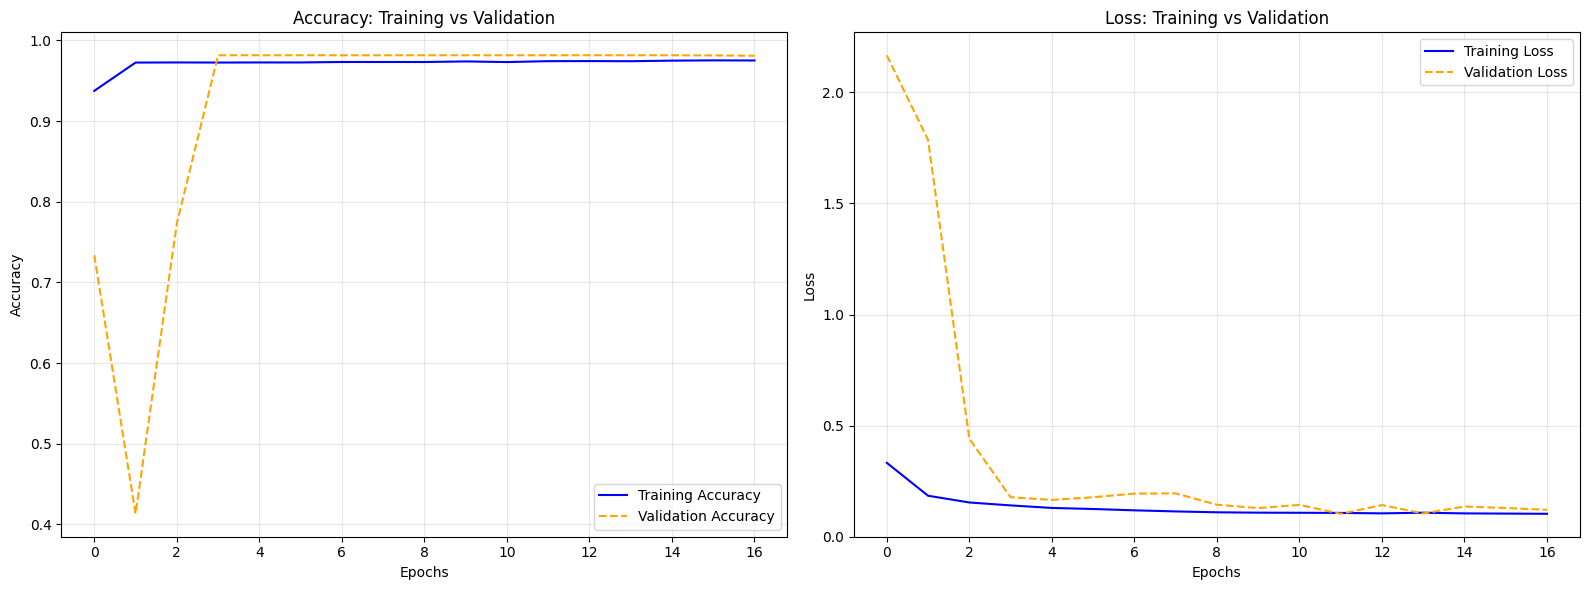

🔍 INTERPRETATION:
- Good Model: Blue and Orange lines move together.
- Overfitting: Blue line goes DOWN, but Orange line goes UP (Stop training!).


In [54]:
# @title 10. Visualize Training History (Train vs Validation)
import matplotlib.pyplot as plt

# 1. Extract Metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# 2. Plotting
plt.figure(figsize=(16, 6))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linestyle='--')
plt.title('Accuracy: Training vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linestyle='--')
plt.title('Loss: Training vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 INTERPRETATION:")
print("- Good Model: Blue and Orange lines move together.")
print("- Overfitting: Blue line goes DOWN, but Orange line goes UP (Stop training!).")

## **11. Global Stress Test: Real-World Inference**

A true "Global" model must perform well across different continents, biomes, and time periods. We stress-test our U-Net on three distinct historic disasters.



### **The Test Cases:**
1.  **🇵🇰 Pakistan (Sindh, 2022):** *The Monsoon Test.* Massive inundation in a semi-arid region with heavy cloud cover.
2.  **🇹🇭 Thailand (Ayutthaya, 2011):** *The Tropical Test.* Flooding in a lush, vegetation-heavy environment. This is challenging because dark green vegetation can sometimes look like water to a satellite.
3.  **🇮🇳 India (Assam, 2020):** *The Morphology Test.*
    * **Target:** The Brahmaputra River.
    * **Challenge:** Unlike the single channel of the Indus, the Brahmaputra is a **Braided River System** consisting of hundreds of interlacing small channels. This tests if the model can detect complex water geometries.

### **Methodology: Cloud-Free Mosaicking**
For each event, we generate a **10-day composite** using the `.min()` reducer.
* **Why?** Major floods are accompanied by storms. Single-day images are often white (cloud-blocked).
* **How:** By taking the minimum pixel value over 10 days, we statistically filter out bright clouds and capture the dark floodwaters underneath.


🌐 Processing: Mozambique - Cyclone Idai (2019)...


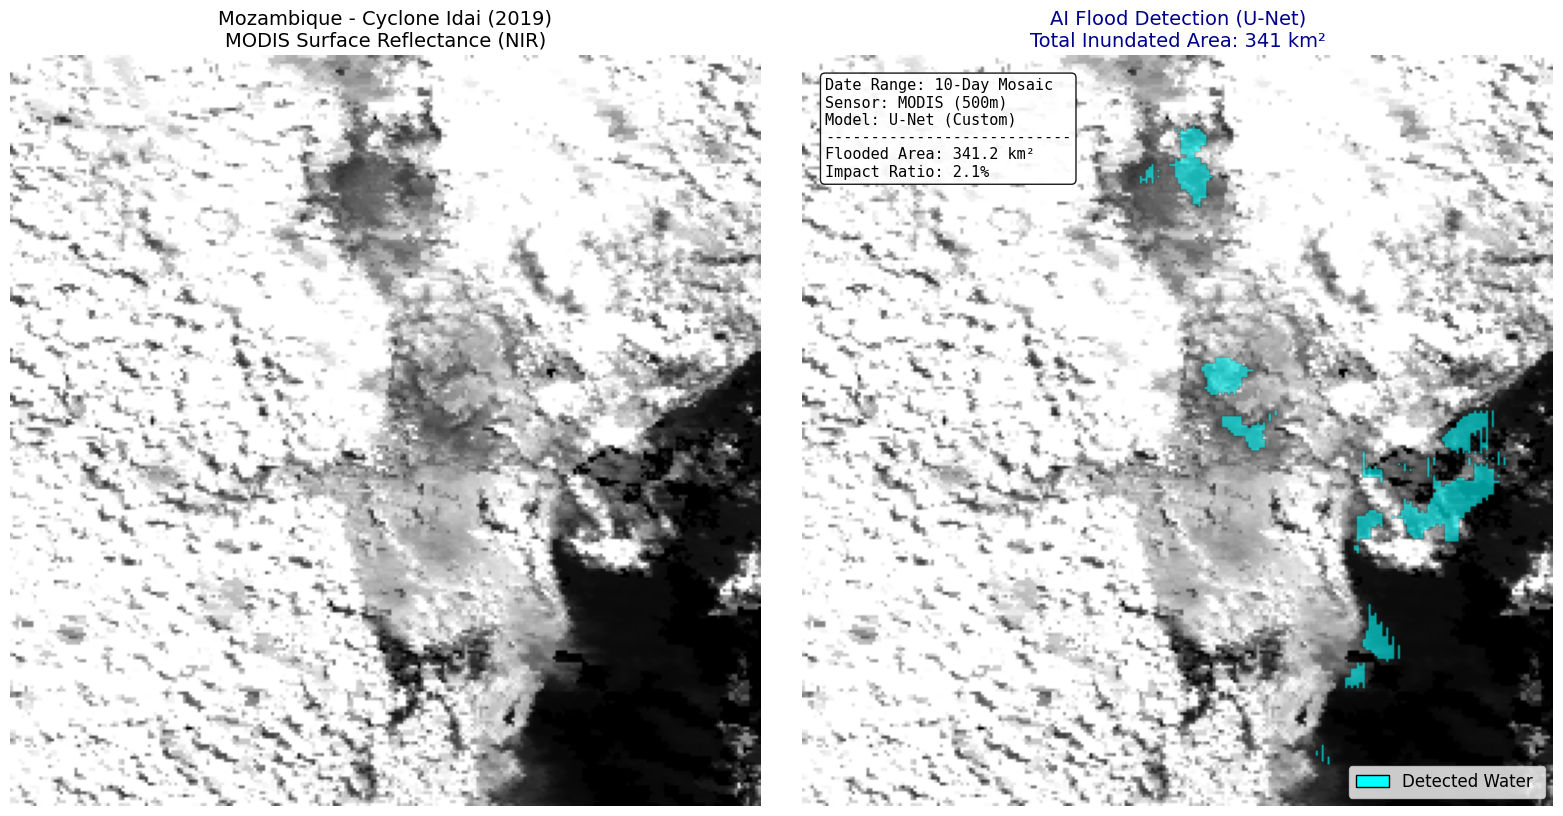


🌐 Processing: India - Bihar Floods (2017)...


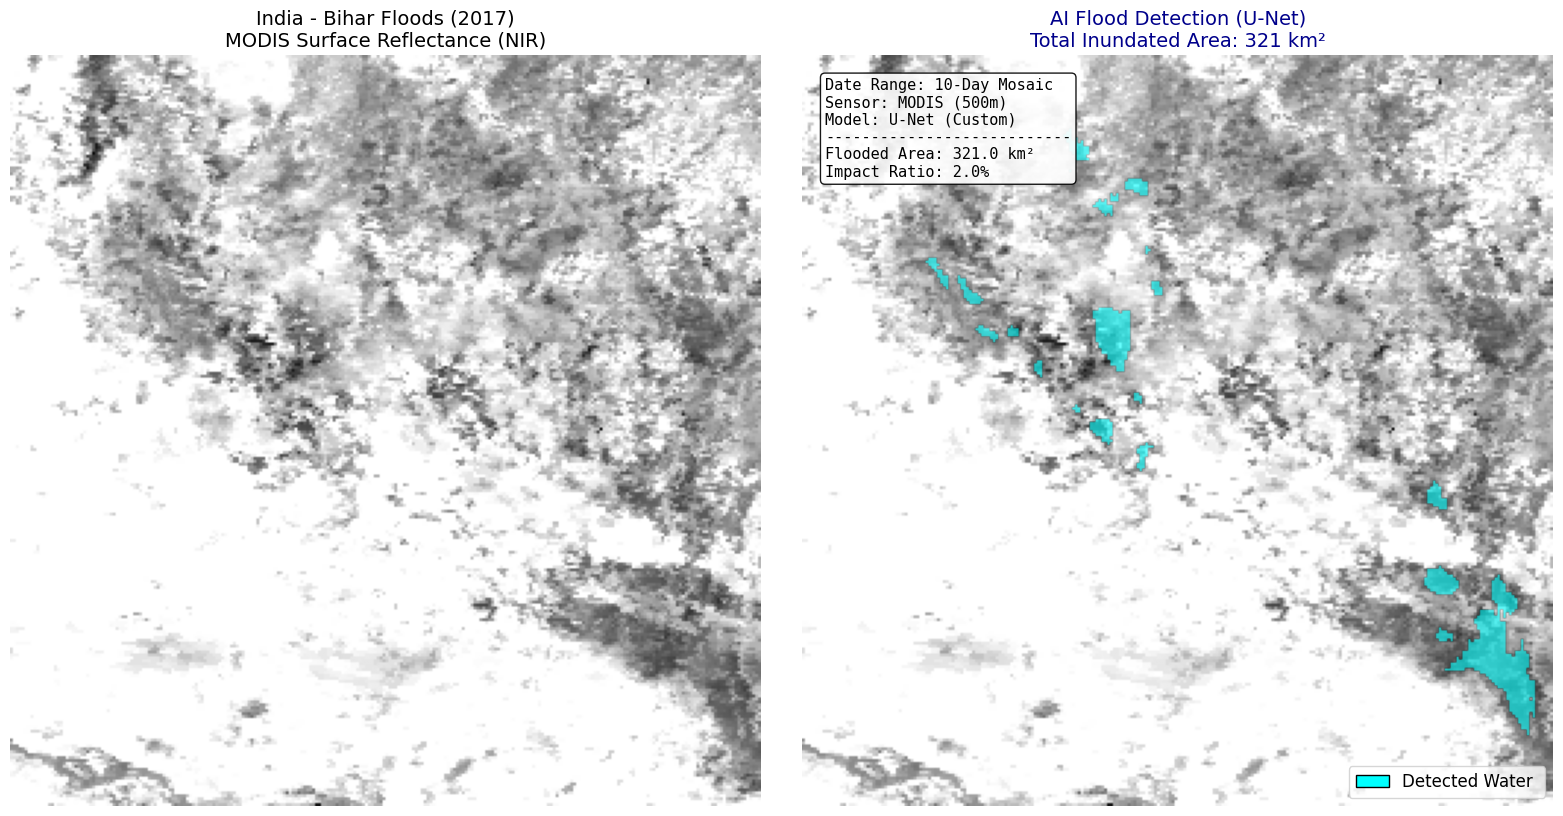


🌐 Processing: Cambodia - Mekong Delta (2011)...


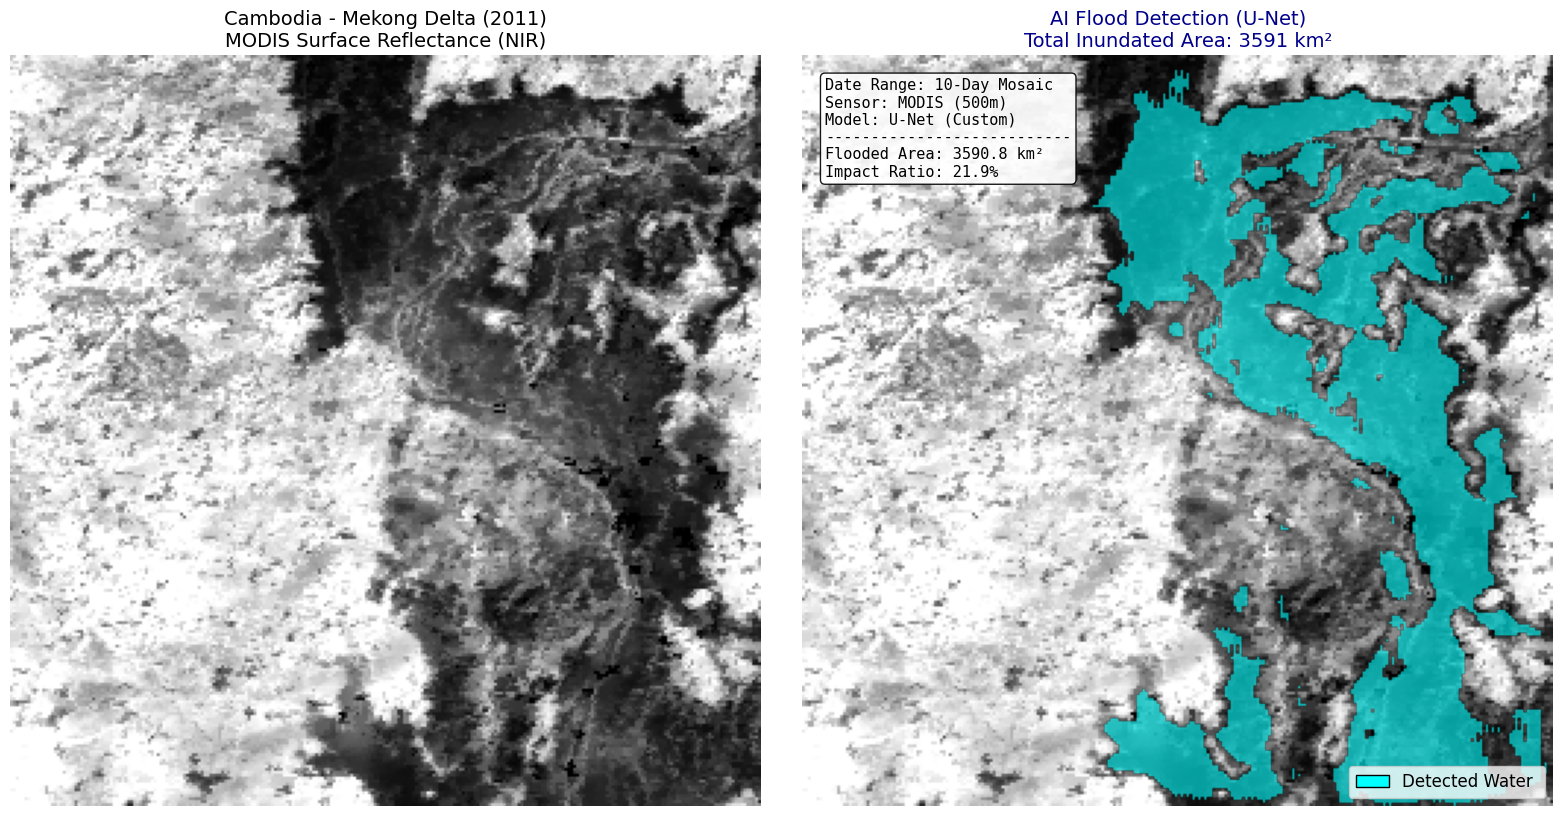


🌐 Processing: Brazil - Amazon Floods (2021)...


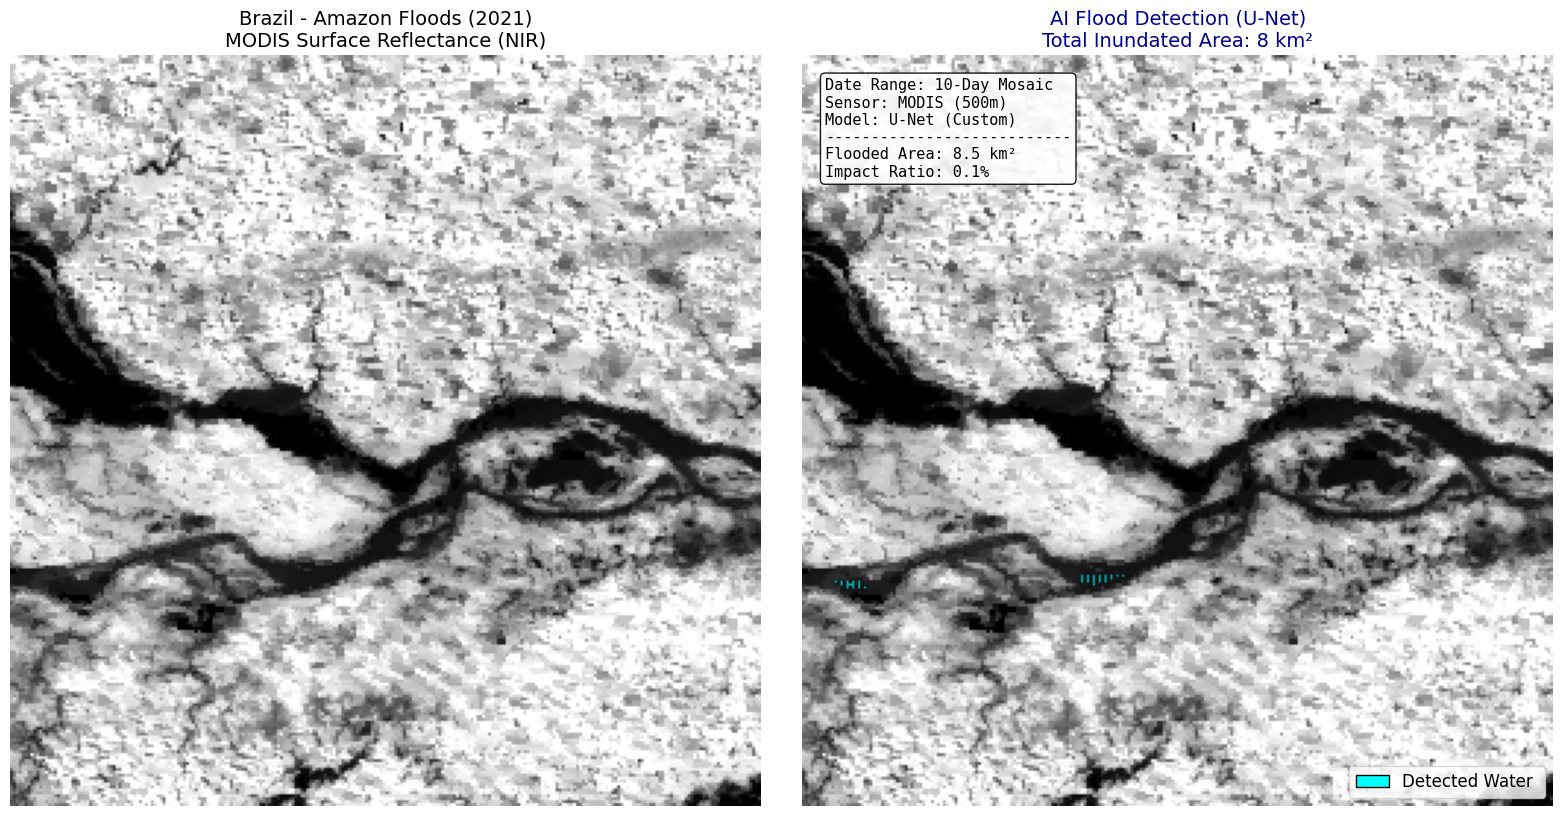


🌐 Processing: Canada - Spring Thaw (2019)...


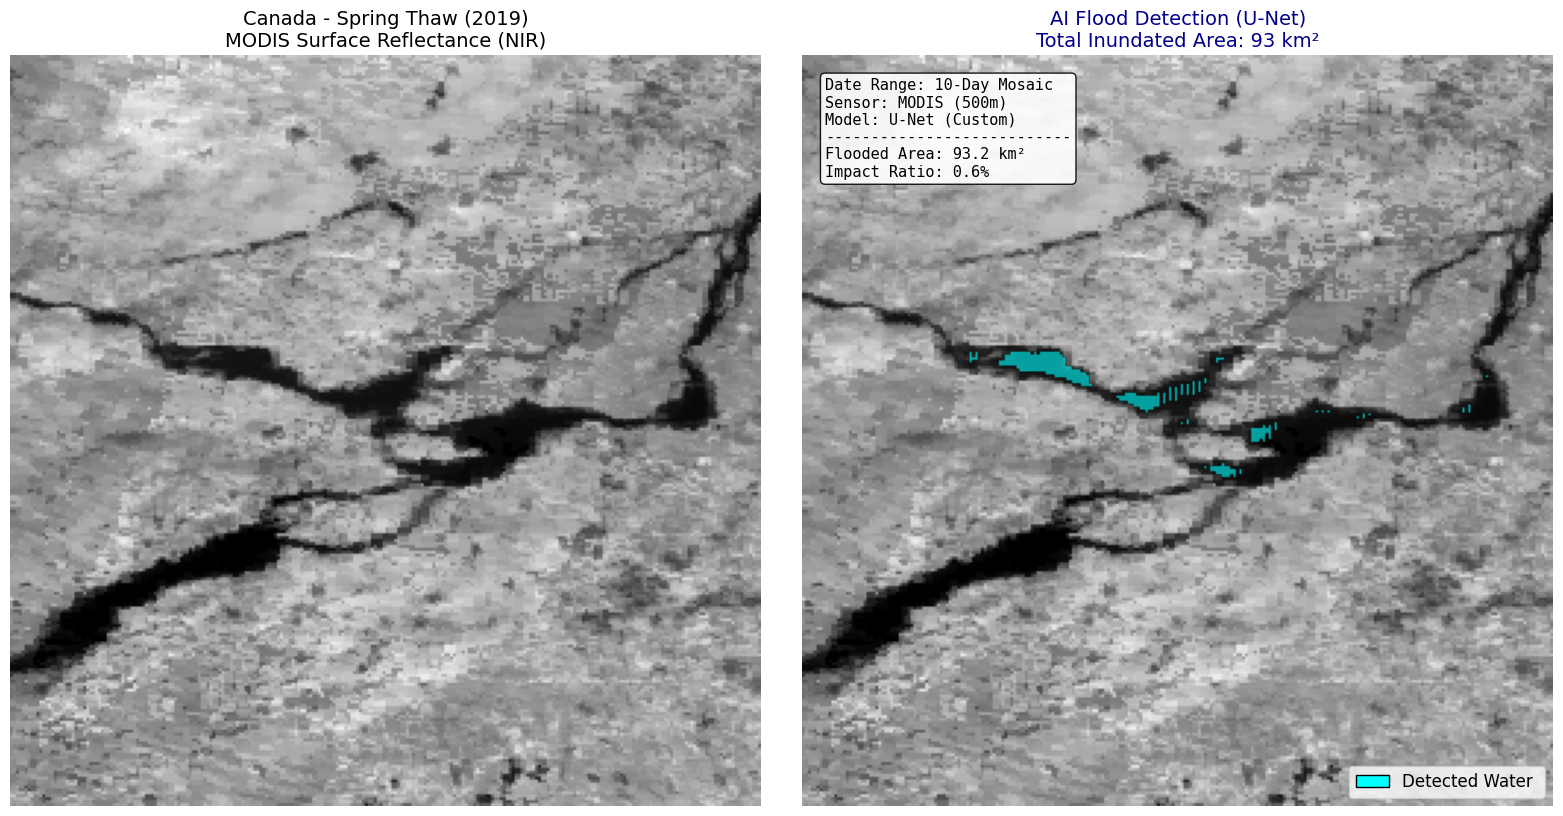

In [55]:
# @title 12. Execute Global Inference Loop
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import ee
from matplotlib.patches import Patch

# --- 1. Define Test Cases (Clean Names) ---
TEST_CASES = [
    {
        "name": "Mozambique - Cyclone Idai (2019)",
        "date_start": "2019-03-15", "date_end": "2019-03-25",
        "lat": -19.85, "lon": 34.50
    },
    {
        "name": "India - Bihar Floods (2017)",
        "date_start": "2017-08-10", "date_end": "2017-08-20",
        "lat": 26.10, "lon": 85.90
    },
    {
        "name": "Cambodia - Mekong Delta (2011)",
        "date_start": "2011-10-10", "date_end": "2011-10-20",
        "lat": 11.5, "lon": 104.9
    },
    {
        "name": "Brazil - Amazon Floods (2021)",
        "date_start": "2021-05-15", "date_end": "2021-05-25",
        "lat": -3.1, "lon": -60.0
    },
    {
        "name": "Canada - Spring Thaw (2019)",
        "date_start": "2019-04-20", "date_end": "2019-04-30",
        "lat": 45.4, "lon": -74.0
    }
]

# --- 2. Helper: Professional Plotting Function ---
def plot_flood_analysis(rgb_img, flood_mask, case_name, area_km2, flood_pct):
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    # Subplot 1: Raw Satellite
    ax[0].imshow(rgb_img, cmap='gray', vmin=0, vmax=0.3)
    ax[0].set_title(f"{case_name}\nMODIS Surface Reflectance (NIR)", fontsize=14)
    ax[0].axis('off')

    # Subplot 2: Analysis Map
    ax[1].imshow(rgb_img, cmap='gray', vmin=0, vmax=0.3)

    # Cyan Overlay
    overlay = np.zeros((256, 256, 4))
    overlay[flood_mask == 1] = [0, 1, 1, 0.6]
    ax[1].imshow(overlay)

    ax[1].set_title(f"AI Flood Detection (U-Net)\nTotal Inundated Area: {area_km2:.0f} km²", fontsize=14, color='darkblue')
    ax[1].axis('off')

    # Legend
    legend_elements = [
        Patch(facecolor='cyan', edgecolor='black', label='Detected Water ')
    ]
    ax[1].legend(handles=legend_elements, loc='lower right', fontsize=12)

    # Info Box
    textstr = '\n'.join((
        f"Date Range: 10-Day Mosaic",
        f"Sensor: MODIS (500m)",
        f"Model: U-Net (Custom)",
        f"---------------------------",
        f"Flooded Area: {area_km2:.1f} km²",
        f"Impact Ratio: {flood_pct:.1f}%"
    ))

    props = dict(boxstyle='round', facecolor='white', alpha=0.9)
    ax[1].text(0.03, 0.97, textstr, transform=ax[1].transAxes, fontsize=11,
            verticalalignment='top', bbox=props, family='monospace')

    plt.tight_layout()
    plt.show()

# --- 3. The Analysis Logic ---
def analyze_flood_event(case):
    print(f"\n🌐 Processing: {case['name']}...")
    point = ee.Geometry.Point([case['lon'], case['lat']])
    region = point.buffer(70000).bounds()

    # Cloud-Free Mosaic
    mosaic = ee.ImageCollection('MODIS/061/MOD09GA') \
        .filterDate(case['date_start'], case['date_end']) \
        .filterBounds(point) \
        .select(['sur_refl_b01', 'sur_refl_b02', 'sur_refl_b06']) \
        .min() \
        .reproject(crs='EPSG:4326', scale=500)

    try:
        sample = mosaic.divide(10000).sampleRectangle(region=region, defaultValue=0)
        b1 = np.array(sample.get('sur_refl_b01').getInfo())
        b2 = np.array(sample.get('sur_refl_b02').getInfo())
        b6 = np.array(sample.get('sur_refl_b06').getInfo())

        rgb_stack = np.dstack((b1, b2, b6))
        input_tensor = tf.convert_to_tensor(rgb_stack, dtype=tf.float32)
        input_tensor = tf.image.resize_with_crop_or_pad(input_tensor, 256, 256)
        rgb_fixed = input_tensor.numpy()

        input_batch = tf.expand_dims(input_tensor, axis=0)
        pred_raw = model.predict(input_batch, verbose=0)

        # Threshold 0.2
        flood_map = pred_raw[0, :, :, 0] > 0.2

        flooded_km2 = np.sum(flood_map) * 0.25
        flood_pct = (np.sum(flood_map) / (256*256)) * 100

        plot_flood_analysis(rgb_fixed[:, :, 1], flood_map, case['name'], flooded_km2, flood_pct)

    except Exception as e:
        print(f"   ❌ Error: {e}")

# --- 4. Execute ---
for case in TEST_CASES:
    analyze_flood_event(case)